# 🛒 Supermarket Sales — Exploratory Data Analysis

## 1. Project Introduction

**Objective:** Analyze three months of transaction-level supermarket sales data to uncover
patterns in revenue, customer behavior, and product performance, and to translate those
patterns into concrete, data-backed business recommendations.

**Dataset description:** The dataset contains **1,000 individual sales transactions** recorded
across **three branches** of a supermarket chain in Myanmar between **January 1, 2019 and
March 30, 2019**. Each row represents one customer invoice and includes the branch/city,
customer type (Member vs. Normal), gender, product line, unit price, quantity purchased, tax,
total amount, payment method, date/time of purchase, cost of goods sold (COGS), gross income,
and the customer's satisfaction rating for that transaction (0–10 scale).

**Business / problem questions this analysis aims to answer:**
1. Which product lines generate the most revenue and profit?
2. Which branch/city performs best, and is performance driven by traffic or basket size?
3. Do Member customers spend more or behave differently than Normal customers?
4. Which payment methods do customers prefer, and does that vary by branch?
5. Are there time-based patterns (day of week, hour of day, month) in sales volume?
6. What drives the total transaction value — price, quantity, or something else?
7. Does customer satisfaction (rating) relate to spend, product line, or branch?
8. Are there outlier transactions, and what do they represent?

**Dataset source:** [Supermarket Sales dataset](https://www.kaggle.com/datasets/aungpyaeap/supermarket-sales)
originally published on Kaggle by Aung Pyae, mirrored in this project's `data/raw/` folder for
reproducibility. See `README.md` for full source and license details.


## 2. Import Libraries

In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Make the reusable src/ functions importable from the notebook
sys.path.append(str(Path.cwd().parent / "src"))
import data_cleaning as dc
import analysis as an

sns.set_theme(style="whitegrid", palette="viridis")
plt.rcParams["figure.dpi"] = 110
plt.rcParams["axes.titlesize"] = 13
plt.rcParams["axes.titleweight"] = "bold"

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 120)


## 3. Load the Dataset

We start from the raw, untouched export in `data/raw/dataset.csv` so that every cleaning
decision made later in this notebook is transparent and reproducible.


In [2]:
raw_df = pd.read_csv("../data/raw/dataset.csv")
print(f"Rows: {raw_df.shape[0]:,}   Columns: {raw_df.shape[1]}")


Rows: 1,000   Columns: 17


In [3]:
raw_df.head()


,Invoice ID,Branch,City,Customer type,Gender,Product line,Unit price,Quantity,Tax 5%,Total,Date,Time,Payment,cogs,gross margin percentage,gross income,Rating
0,750-67-8428,A,Yangon,Member,Female,Health and beauty,74.69,7,26.1415,548.9715,1/5/2019,13:08,Ewallet,522.83,4.761905,26.1415,9.1
1,226-31-3081,C,Naypyitaw,Normal,Female,Electronic accessories,15.28,5,3.8200,80.2200,3/8/2019,10:29,Cash,76.40,4.761905,3.8200,9.6
2,631-41-3108,A,Yangon,Normal,Male,Home and lifestyle,46.33,7,16.2155,340.5255,3/3/2019,13:23,Credit card,324.31,4.761905,16.2155,7.4
3,123-19-1176,A,Yangon,Member,Male,Health and beauty,58.22,8,23.2880,489.0480,1/27/2019,20:33,Ewallet,465.76,4.761905,23.2880,8.4
4,373-73-7910,A,Yangon,Normal,Male,Sports and travel,86.31,7,30.2085,634.3785,2/8/2019,10:37,Ewallet,604.17,4.761905,30.2085,5.3


In [4]:
raw_df.tail()


,Invoice ID,Branch,City,Customer type,Gender,Product line,Unit price,Quantity,Tax 5%,Total,Date,Time,Payment,cogs,gross margin percentage,gross income,Rating
995,233-67-5758,C,Naypyitaw,Normal,Male,Health and beauty,40.35,1,2.0175,42.3675,1/29/2019,13:46,Ewallet,40.35,4.761905,2.0175,6.2
996,303-96-2227,B,Mandalay,Normal,Female,Home and lifestyle,97.38,10,48.6900,1022.4900,3/2/2019,17:16,Ewallet,973.80,4.761905,48.6900,4.4
997,727-02-1313,A,Yangon,Member,Male,Food and beverages,31.84,1,1.5920,33.4320,2/9/2019,13:22,Cash,31.84,4.761905,1.5920,7.7
998,347-56-2442,A,Yangon,Normal,Male,Home and lifestyle,65.82,1,3.2910,69.1110,2/22/2019,15:33,Cash,65.82,4.761905,3.2910,4.1
999,849-09-3807,A,Yangon,Member,Female,Fashion accessories,88.34,7,30.9190,649.2990,2/18/2019,13:28,Cash,618.38,4.761905,30.9190,6.6


In [5]:
print("Column names:")
print(list(raw_df.columns))


Column names:
['Invoice ID', 'Branch', 'City', 'Customer type', 'Gender', 'Product line', 'Unit price', 'Quantity', 'Tax 5%', 'Total', 'Date', 'Time', 'Payment', 'cogs', 'gross margin percentage', 'gross income', 'Rating']


In [6]:
raw_df.dtypes


Invoice ID                     str
Branch                         str
City                           str
Customer type                  str
Gender                         str
Product line                   str
Unit price                 float64
Quantity                     int64
Tax 5%                     float64
Total                      float64
Date                           str
Time                           str
Payment                        str
cogs                       float64
gross margin percentage    float64
gross income               float64
Rating                     float64
dtype: object

## 4. Data Understanding

Before cleaning anything, we build a full picture of the dataset's shape, structure, and
value ranges.


In [7]:
raw_df.shape


(1000, 17)

In [8]:
raw_df.info()


<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 17 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Invoice ID               1000 non-null   str    
 1   Branch                   1000 non-null   str    
 2   City                     1000 non-null   str    
 3   Customer type            1000 non-null   str    
 4   Gender                   1000 non-null   str    
 5   Product line             1000 non-null   str    
 6   Unit price               1000 non-null   float64
 7   Quantity                 1000 non-null   int64  
 8   Tax 5%                   1000 non-null   float64
 9   Total                    1000 non-null   float64
 10  Date                     1000 non-null   str    
 11  Time                     1000 non-null   str    
 12  Payment                  1000 non-null   str    
 13  cogs                     1000 non-null   float64
 14  gross margin percentage  1000 non-nu

In [9]:
raw_df.describe()


,Unit price,Quantity,Tax 5%,Total,cogs,gross margin percentage,gross income,Rating
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.00000,1000.000000,1000.000000,1000.00000
mean,55.672130,5.510000,15.379369,322.966749,307.58738,4.761905,15.379369,6.97270
std,26.494628,2.923431,11.708825,245.885335,234.17651,0.000000,11.708825,1.71858
min,10.080000,1.000000,0.508500,10.678500,10.17000,4.761905,0.508500,4.00000
25%,32.875000,3.000000,5.924875,124.422375,118.49750,4.761905,5.924875,5.50000
50%,55.230000,5.000000,12.088000,253.848000,241.76000,4.761905,12.088000,7.00000
75%,77.935000,8.000000,22.445250,471.350250,448.90500,4.761905,22.445250,8.50000
max,99.960000,10.000000,49.650000,1042.650000,993.00000,4.761905,49.650000,10.00000


In [10]:
print("Unique values per categorical column:\n")
for col in ["Branch", "City", "Customer type", "Gender", "Product line", "Payment"]:
    print(f"{col:16s} -> {raw_df[col].nunique()} unique: {sorted(raw_df[col].unique())}")


Unique values per categorical column:

Branch           -> 3 unique: ['A', 'B', 'C']
City             -> 3 unique: ['Mandalay', 'Naypyitaw', 'Yangon']
Customer type    -> 2 unique: ['Member', 'Normal']
Gender           -> 2 unique: ['Female', 'Male']
Product line     -> 6 unique: ['Electronic accessories', 'Fashion accessories', 'Food and beverages', 'Health and beauty', 'Home and lifestyle', 'Sports and travel']
Payment          -> 3 unique: ['Cash', 'Credit card', 'Ewallet']


**Observations:**
- The dataset has **1,000 rows and 17 columns** — a manageable but sufficiently large sample
  for meaningful statistical summaries and visual patterns.
- There are **6 categorical variables** (Branch, City, Customer type, Gender, Product line,
  Payment) and **7 numeric variables** (Unit price, Quantity, Tax 5%, Total, cogs, gross income,
  Rating), plus Date/Time fields that need to be converted from text to proper datetime types.
- `Total`, `Tax 5%`, `cogs`, and `gross income` are all mathematically derived from
  `Unit price × Quantity`, which we verify explicitly in the Data Cleaning section below and
  keep in mind during correlation analysis (their correlation with `Total` will be ≈ 1.0 by
  construction, not because of a meaningful independent relationship).
- `Rating` is the only variable representing customer sentiment rather than a financial metric,
  which makes it a key variable for the "what drives satisfaction" business question.


## 5. Data Cleaning

We use the reusable functions in `src/data_cleaning.py` so that this exact pipeline can be
re-run on a refreshed export at any time. Every step below prints *before/after* evidence
rather than silently transforming the data.

### 5.1 Missing values


In [11]:
missing_counts = dc.check_missing_values(raw_df)
missing_counts


Invoice ID                 0
Branch                     0
City                       0
Customer type              0
Gender                     0
Product line               0
Unit price                 0
Quantity                   0
Tax 5%                     0
Total                      0
Date                       0
Time                       0
Payment                    0
cogs                       0
gross margin percentage    0
gross income               0
Rating                     0
dtype: int64

**Finding:** The dataset contains **zero missing values** across all 17 columns. This is a
genuinely clean, well-curated export (point-of-sale systems rarely allow an incomplete invoice
to be saved), so no imputation or row-dropping was necessary. We still show the check here
rather than skip it, because verifying data completeness is a mandatory first step in any real
EDA — even when the answer turns out to be "nothing to fix."


### 5.2 Duplicate records

In [12]:
n_duplicates = dc.check_duplicates(raw_df)
print(f"Fully duplicated rows: {n_duplicates}")


Fully duplicated rows: 0


**Finding:** No duplicate invoices were found — each `Invoice ID` is unique, as expected for point-of-sale data.

### 5.3 Column naming & data types

Raw column headers such as `"Tax 5%"` and `"Customer type"` are not convenient for code, and
`Date` / `Time` are stored as plain text rather than datetime objects. We standardize both.


In [13]:
df = dc.standardize_column_names(raw_df)
df = dc.standardize_categorical_values(df)
print("Dtypes before fixing date/time:")
print(df[["date", "time"]].dtypes)
df = dc.fix_data_types(df)
print("\nDtypes after fixing date/time:")
print(df[["date", "time"]].dtypes)


Dtypes before fixing date/time:
date    str
time    str
dtype: object

Dtypes after fixing date/time:
date    datetime64[us]
time            object
dtype: object


### 5.4 Feature engineering (date-derived columns)

To answer the time-pattern business questions (day-of-week, hour-of-day, seasonality), we
derive `month`, `day_of_week`, and `hour` columns from the cleaned `date`/`time` fields.


In [14]:
df = dc.engineer_date_features(df)
df[["date", "time", "month", "day_of_week", "hour"]].head()


,date,time,month,day_of_week,hour
0,2019-01-05,13:08:00,January,Saturday,13
1,2019-03-08,10:29:00,March,Friday,10
2,2019-03-03,13:23:00,March,Sunday,13
3,2019-01-27,20:33:00,January,Sunday,20
4,2019-02-08,10:37:00,February,Friday,10


### 5.5 Business-rule validation

Beyond generic missing-value/duplicate checks, we validate domain-specific rules that a
genuinely clean retail dataset must satisfy: no non-positive prices/quantities, the `total`
column must equal `unit_price × quantity × 1.05` (5% tax), and `rating` must fall within its
documented 0–10 scale.


In [15]:
validation_results = dc.validate_business_rules(df)
validation_results


{'negative_quantity_rows': 0,
 'negative_unit_price_rows': 0,
 'total_formula_mismatches': 0,
 'rating_out_of_range': 0}

**Finding:** All business-rule checks pass — 0 invalid rows across every check. This confirms
the `Total` column is fully explained by `Unit price × Quantity × 1.05`, which is important
context we carry into the correlation analysis later (it explains the perfect correlations we
will see between `total`, `tax_5_pct`, `cogs`, and `gross_income`).


### 5.6 Outlier detection (IQR method)

In [16]:
for col in ["total", "quantity", "unit_price", "rating"]:
    outlier_mask = dc.detect_outliers_iqr(df, col)
    print(f"{col:12s}: {outlier_mask.sum()} outliers out of {len(df)} rows "
          f"({outlier_mask.mean()*100:.1f}%)")


total       : 9 outliers out of 1000 rows (0.9%)
quantity    : 0 outliers out of 1000 rows (0.0%)
unit_price  : 0 outliers out of 1000 rows (0.0%)
rating      : 0 outliers out of 1000 rows (0.0%)


**Finding:** Only the `total` column shows outliers (9 transactions, 0.9% of the data) —
these are large, high-value baskets rather than data-entry errors, so they are **kept in the
dataset** and flagged for interpretation rather than removed. `quantity`, `unit_price`, and
`rating` show no statistical outliers under the 1.5×IQR rule.


### 5.7 Inconsistent categorical values

In [17]:
for col in ["branch", "city", "customer_type", "gender", "product_line", "payment"]:
    print(f"{col:16s} -> {sorted(df[col].unique())}")


branch           -> ['A', 'B', 'C']
city             -> ['Mandalay', 'Naypyitaw', 'Yangon']
customer_type    -> ['Member', 'Normal']
gender           -> ['Female', 'Male']
product_line     -> ['Electronic accessories', 'Fashion accessories', 'Food and beverages', 'Health and beauty', 'Home and lifestyle', 'Sports and travel']
payment          -> ['Cash', 'Credit card', 'Ewallet']


**Finding:** All categorical fields use consistent, single-format labels (no casing/whitespace variants), so no re-mapping was required beyond the defensive `.strip()` applied in `standardize_categorical_values()`.

### 5.8 Save the cleaned dataset

In [18]:
dc.save_cleaned_data(df)
df.head()



Cleaned dataset saved to: /home/claude/proj/Exploratory-Data-Analysis-Project/data/cleaned/cleaned_dataset.csv


,invoice_id,branch,city,customer_type,gender,product_line,unit_price,quantity,tax_5_pct,total,date,time,payment,cogs,gross_margin_pct,gross_income,rating,month,month_num,day_of_week,hour
0,750-67-8428,A,Yangon,Member,Female,Health and beauty,74.69,7,26.1415,548.9715,2019-01-05,13:08:00,Ewallet,522.83,4.761905,26.1415,9.1,January,1,Saturday,13
1,226-31-3081,C,Naypyitaw,Normal,Female,Electronic accessories,15.28,5,3.8200,80.2200,2019-03-08,10:29:00,Cash,76.40,4.761905,3.8200,9.6,March,3,Friday,10
2,631-41-3108,A,Yangon,Normal,Male,Home and lifestyle,46.33,7,16.2155,340.5255,2019-03-03,13:23:00,Credit card,324.31,4.761905,16.2155,7.4,March,3,Sunday,13
3,123-19-1176,A,Yangon,Member,Male,Health and beauty,58.22,8,23.2880,489.0480,2019-01-27,20:33:00,Ewallet,465.76,4.761905,23.2880,8.4,January,1,Sunday,20
4,373-73-7910,A,Yangon,Normal,Male,Sports and travel,86.31,7,30.2085,634.3785,2019-02-08,10:37:00,Ewallet,604.17,4.761905,30.2085,5.3,February,2,Friday,10


## 6. Univariate Analysis

We now examine individual variables in isolation, starting with the numeric fields most
relevant to the business questions: `total`, `unit_price`, `quantity`, and `rating`.


In [19]:
cleaned_df = an.load_cleaned_data()
an.summary_statistics(cleaned_df, ["unit_price", "quantity", "total", "rating"])


,count,mean,std,min,25%,50%,75%,max,median,skew
unit_price,1000.0,55.672130,26.494628,10.0800,32.875000,55.230,77.93500,99.96,55.230,0.007077
quantity,1000.0,5.510000,2.923431,1.0000,3.000000,5.000,8.00000,10.00,5.000,0.012941
total,1000.0,322.966749,245.885335,10.6785,124.422375,253.848,471.35025,1042.65,253.848,0.892570
rating,1000.0,6.972700,1.718580,4.0000,5.500000,7.000,8.50000,10.00,7.000,0.009010


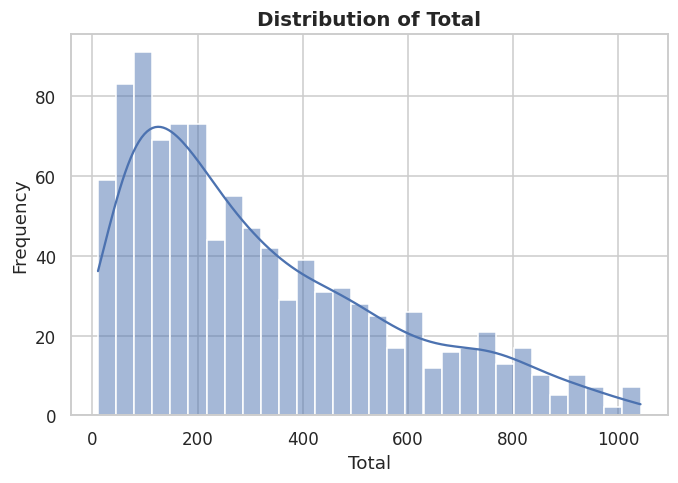

In [20]:
an.plot_numeric_distribution(cleaned_df, "total")
plt.show()


**Interpretation:** Transaction totals are right-skewed — most invoices fall between roughly
\$50 and \$400, with a long tail of larger baskets up to just above \$1,000. This is typical
of retail basket-size distributions and confirms the 9 IQR outliers identified earlier sit at
the extreme end of this tail rather than being anomalous errors.


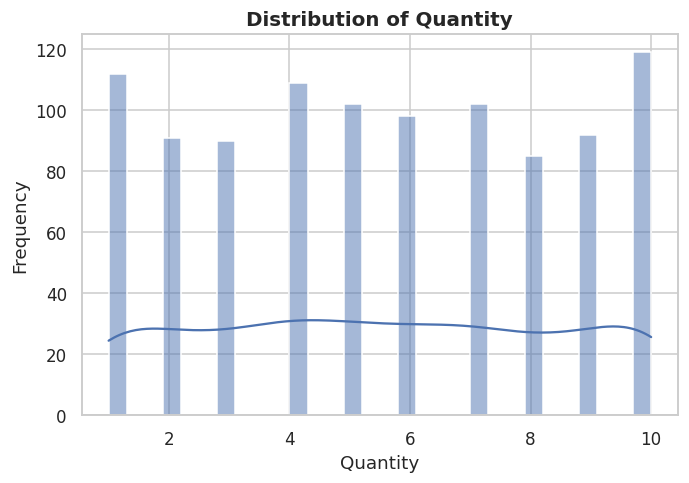

In [21]:
an.plot_numeric_distribution(cleaned_df, "quantity")
plt.show()


**Interpretation:** `quantity` is close to uniformly distributed between 1 and 10 units per line item, with no single quantity dominating — customers do not cluster around a typical basket size, which suggests purchase quantity is driven by individual need rather than promotions or fixed pack sizes.

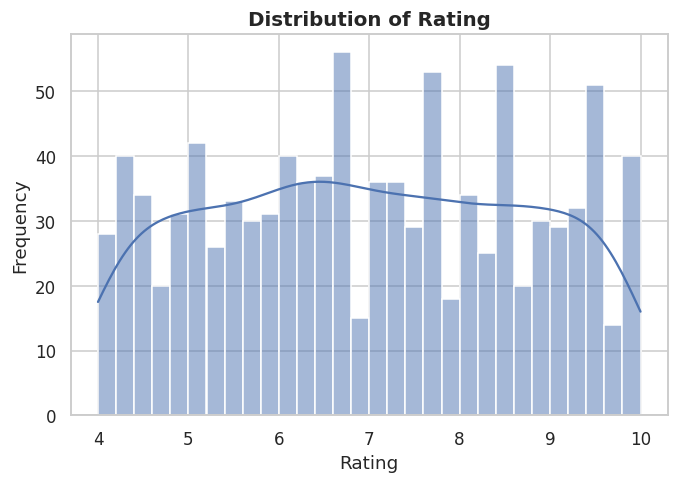

In [22]:
an.plot_numeric_distribution(cleaned_df, "rating")
plt.show()


**Interpretation:** Customer ratings cluster in the 4–10 range with a fairly flat distribution and mean around 7.0, showing no strong ceiling or floor effect — customers are willing to give both high and low scores, so the rating field carries real discriminating signal for later analysis.

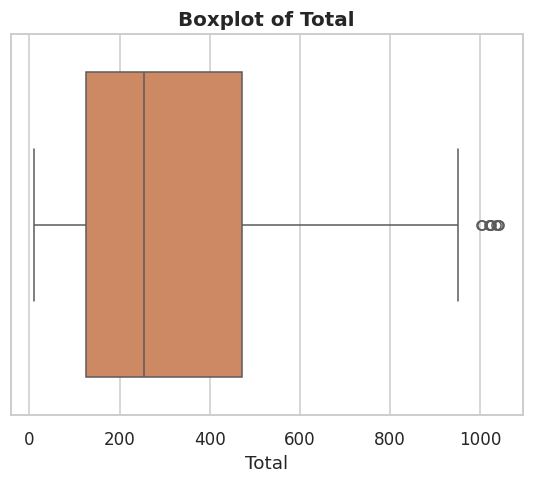

In [23]:
an.plot_boxplot(cleaned_df, "total")
plt.show()


**Interpretation:** The boxplot makes the 9 high-value outlier transactions clearly visible above the upper whisker (~\$630). These represent legitimate large purchases (high unit price and/or high quantity together), not corrupted data.

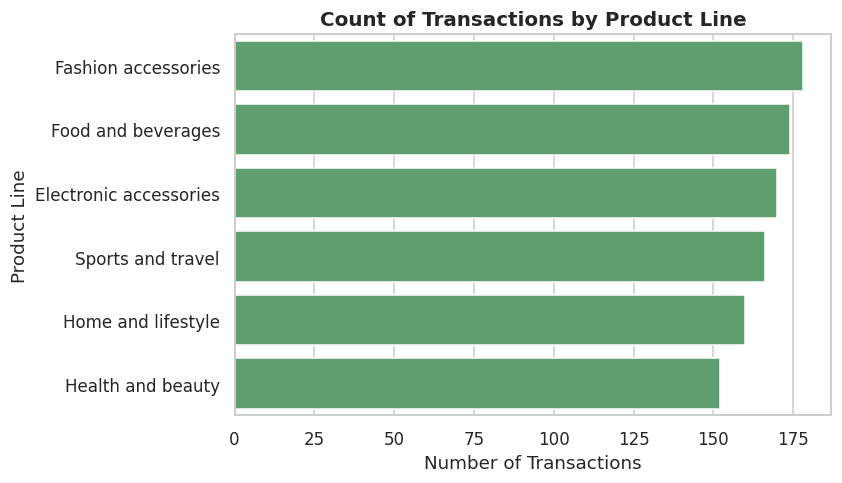

In [24]:
an.plot_categorical_count(cleaned_df, "product_line")
plt.show()


**Interpretation:** Transaction volume is well balanced across the six product lines (each between roughly 150–180 transactions), so no single category dominates simply due to higher transaction frequency — differences in revenue (analyzed next) are therefore driven more by basket value than by popularity.

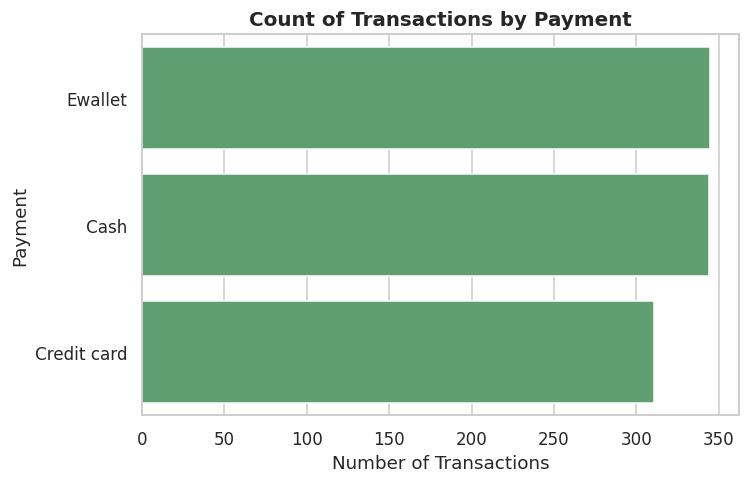

In [25]:
an.plot_categorical_count(cleaned_df, "payment")
plt.show()


**Interpretation:** Cash is the single most common payment method, with Ewallet a close second and Credit card somewhat less frequent — customers show a mild preference for cash and digital wallets over cards at checkout.

## 7. Bivariate Analysis

Next we study relationships *between pairs* of variables to start identifying what drives
revenue, satisfaction, and branch performance.


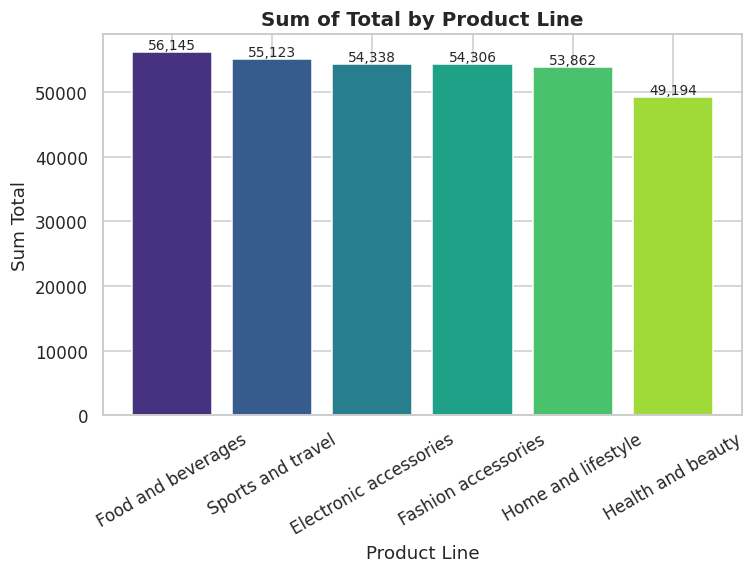

In [26]:
an.plot_grouped_bar(cleaned_df, "product_line", "total")
plt.show()


In [27]:
cleaned_df.groupby("product_line")["total"].agg(["sum", "mean", "count"]).sort_values("sum", ascending=False)


,sum,mean,count
product_line,,,
Food and beverages,56144.8440,322.671517,174
Sports and travel,55122.8265,332.065220,166
Electronic accessories,54337.5315,319.632538,170
Fashion accessories,54305.8950,305.089298,178
Home and lifestyle,53861.9130,336.636956,160
Health and beauty,49193.7390,323.643020,152


**Interpretation:** **Food and beverages** generates the highest total revenue
(≈ \$56,145), narrowly ahead of Sports and travel (≈ \$55,123) and Electronic accessories
(≈ \$54,338). **Health and beauty** is the weakest performer (≈ \$49,194) — about 12% below
the top category — despite having a similar number of transactions, indicating its average
basket value is lower rather than it being unpopular.


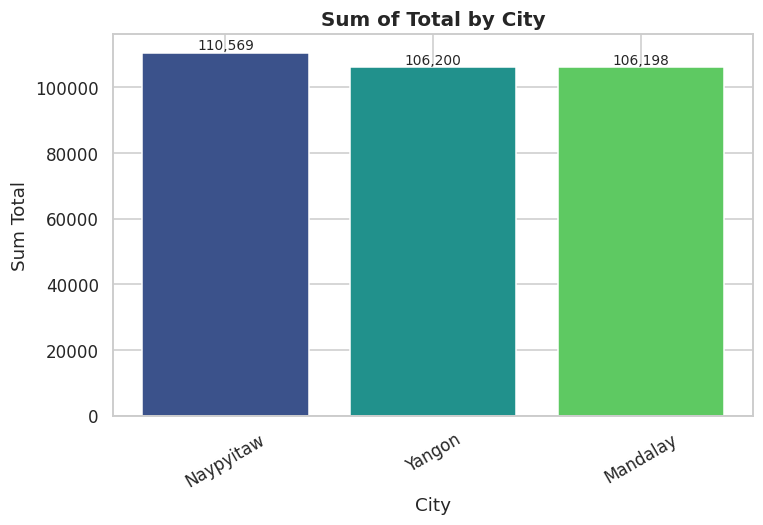

In [28]:
an.plot_grouped_bar(cleaned_df, "city", "total")
plt.show()


In [29]:
cleaned_df.groupby(["branch", "city"])["total"].agg(["sum", "mean", "count"]).sort_values("sum", ascending=False)


,,sum,mean,count
branch,city,,,
C,Naypyitaw,110568.7065,337.099715,328
A,Yangon,106200.3705,312.354031,340
B,Mandalay,106197.6720,319.872506,332


**Interpretation:** Branch **C (Naypyitaw)** leads in total revenue (≈ \$110,569) despite
having the fewest transactions (328) of the three branches — its average basket value is
noticeably higher, meaning Naypyitaw customers spend more per visit rather than visiting more
often. Branches A (Yangon) and B (Mandalay) are nearly tied (≈ \$106,200 each) with more
transactions but smaller average baskets.


/tmp/ipykernel_615/1983476205.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=cleaned_df, x="customer_type", y="total", palette="viridis")


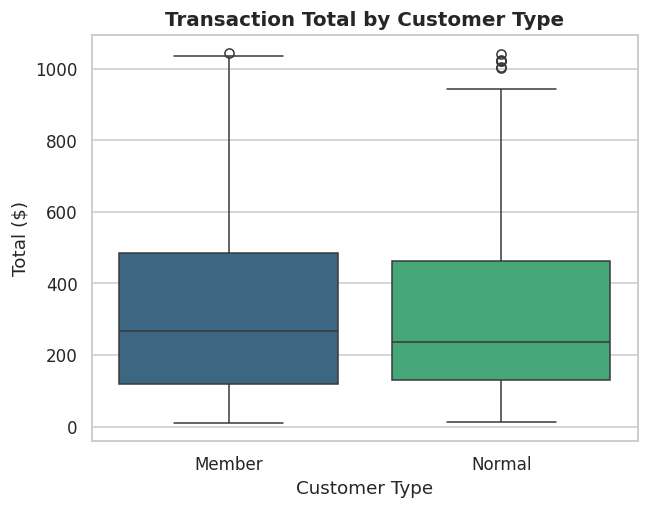

In [30]:
sns.boxplot(data=cleaned_df, x="customer_type", y="total", palette="viridis")
plt.title("Transaction Total by Customer Type")
plt.ylabel("Total ($)")
plt.xlabel("Customer Type")
plt.show()


In [31]:
cleaned_df.groupby("customer_type")["total"].agg(["sum", "mean", "count"])


,sum,mean,count
customer_type,,,
Member,164223.444,327.791305,501
Normal,158743.305,318.122856,499


**Interpretation:** Member customers generate slightly higher total revenue
(≈ \$164,223 vs ≈ \$158,743 for Normal customers) despite an almost identical transaction
count (501 vs 499), meaning membership is associated with a modestly larger average basket
rather than materially more frequent visits within this 3-month window.


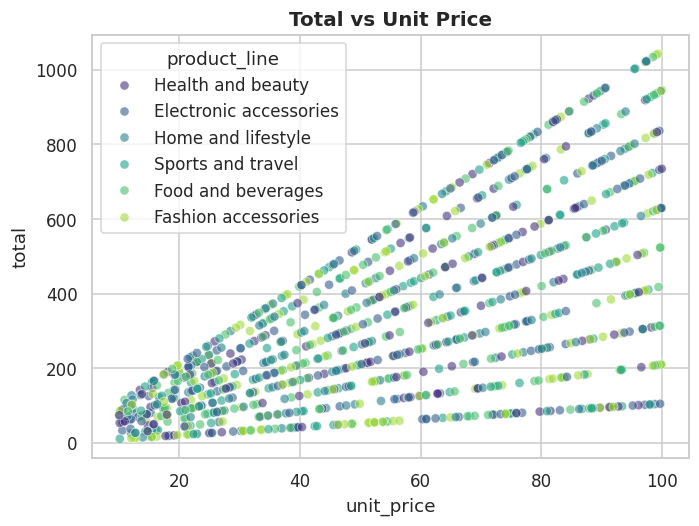

In [32]:
an.plot_scatter(cleaned_df, "unit_price", "total", hue="product_line")
plt.show()


**Interpretation:** `total` rises with `unit_price` but the relationship is far from a tight line — for any given unit price, totals vary substantially depending on quantity purchased, showing that basket value is a *joint* function of price and quantity rather than price alone.

/home/claude/proj/Exploratory-Data-Analysis-Project/src/analysis.py:133: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.scatterplot(data=df, x=x, y=y, hue=hue, alpha=0.6, ax=ax, palette="viridis")


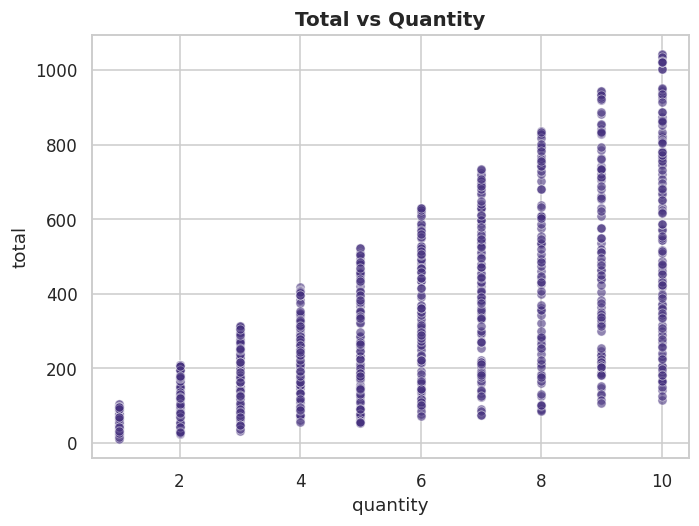

In [33]:
an.plot_scatter(cleaned_df, "quantity", "total")
plt.show()


**Interpretation:** `total` increases with `quantity` more consistently than with `unit_price` alone (correlation of 0.71 vs 0.63, confirmed in the correlation matrix below), suggesting quantity purchased is a slightly stronger lever on basket size than the price of individual items.

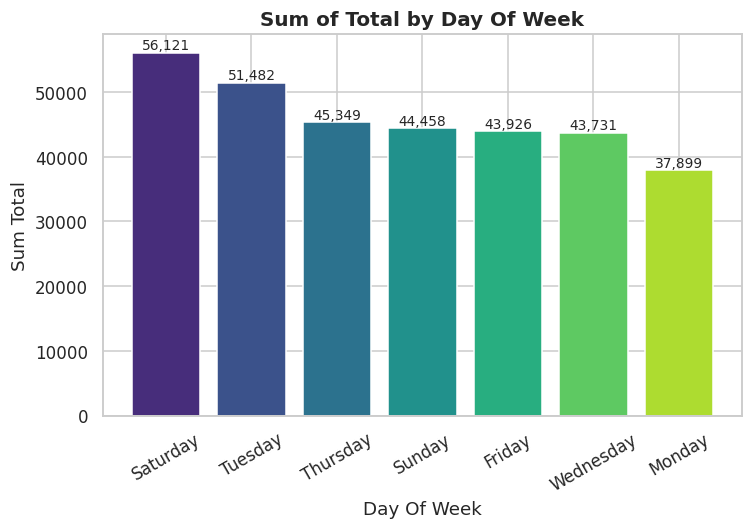

In [34]:
an.plot_grouped_bar(cleaned_df, "day_of_week", "total")
plt.show()


**Interpretation:** **Saturday** is the strongest sales day (≈ \$56,121), roughly 48% higher than the weakest day, **Monday** (≈ \$37,899) — a clear weekend-shopping pattern that has direct implications for staffing and promotional timing.

/tmp/ipykernel_615/357957899.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=cleaned_df, x="product_line", y="rating", palette="viridis")


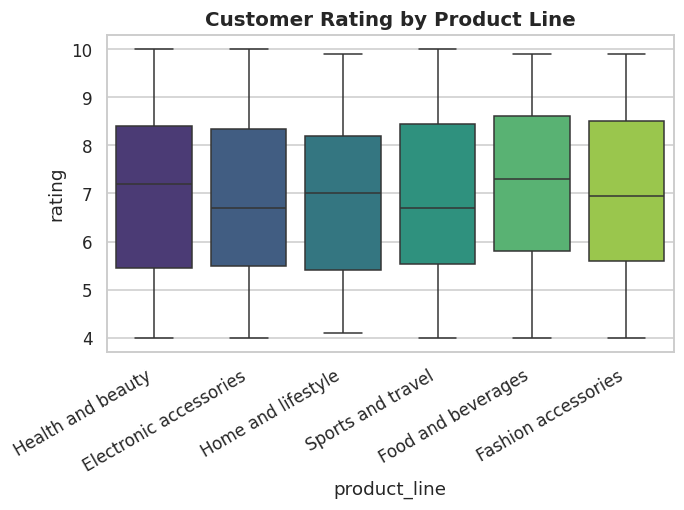

In [35]:
sns.boxplot(data=cleaned_df, x="product_line", y="rating", palette="viridis")
plt.xticks(rotation=30, ha="right")
plt.title("Customer Rating by Product Line")
plt.tight_layout()
plt.show()


**Interpretation:** Average ratings are fairly close across product lines (6.8–7.1), with **Food and beverages** rated highest and **Home and lifestyle** rated lowest — a small but consistent gap that lines up with Food and beverages also being the top revenue generator, hinting that satisfaction and spend may reinforce each other in that category.

## 8. Multivariate Analysis

We now look at three or more variables together to identify deeper, possibly confounded
relationships.


In [36]:
corr = an.correlation_matrix(cleaned_df)
corr


,unit_price,quantity,tax_5_pct,total,cogs,gross_income,rating
unit_price,1.000000,0.010778,0.633962,0.633962,0.633962,0.633962,-0.008778
quantity,0.010778,1.000000,0.705510,0.705510,0.705510,0.705510,-0.015815
tax_5_pct,0.633962,0.705510,1.000000,1.000000,1.000000,1.000000,-0.036442
total,0.633962,0.705510,1.000000,1.000000,1.000000,1.000000,-0.036442
cogs,0.633962,0.705510,1.000000,1.000000,1.000000,1.000000,-0.036442
gross_income,0.633962,0.705510,1.000000,1.000000,1.000000,1.000000,-0.036442
rating,-0.008778,-0.015815,-0.036442,-0.036442,-0.036442,-0.036442,1.000000


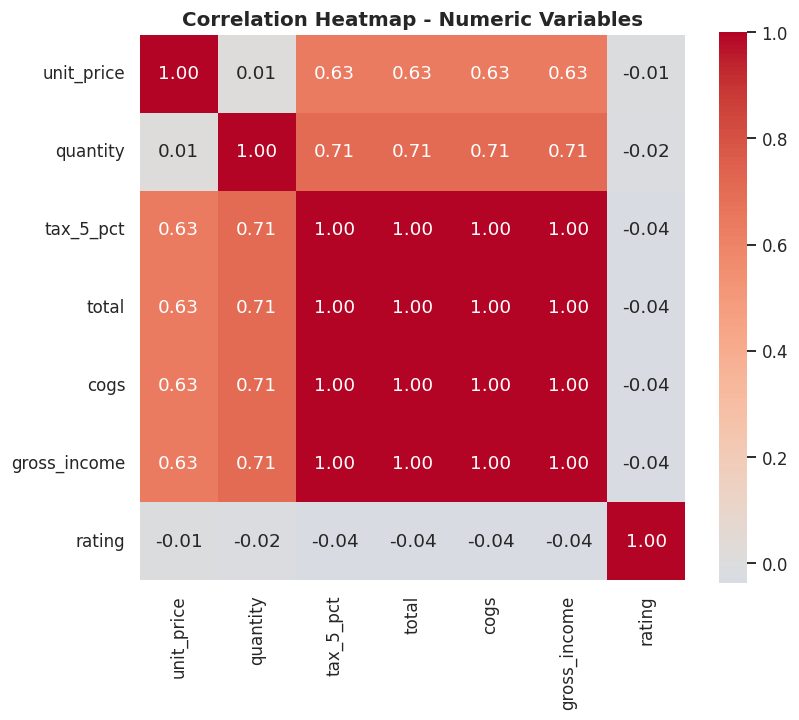

In [37]:
an.plot_correlation_heatmap(cleaned_df)
plt.show()


**Interpretation:** `total`, `tax_5_pct`, `cogs`, and `gross_income` are perfectly correlated
(r = 1.00) with each other **by construction** — they are all derived from
`unit_price × quantity × 1.05`, not independent business signals, so we treat them as a single
"revenue" concept rather than four separate findings. Among the genuinely independent drivers,
`quantity` (r = 0.71) has a stronger relationship with `total` than `unit_price` (r = 0.63),
confirming the bivariate scatterplot finding above. Critically, **`rating` shows essentially no
correlation with any financial variable** (all |r| < 0.05) — customers who spend more do not
rate their experience meaningfully higher or lower, which is an important and slightly
counter-intuitive insight for the business.


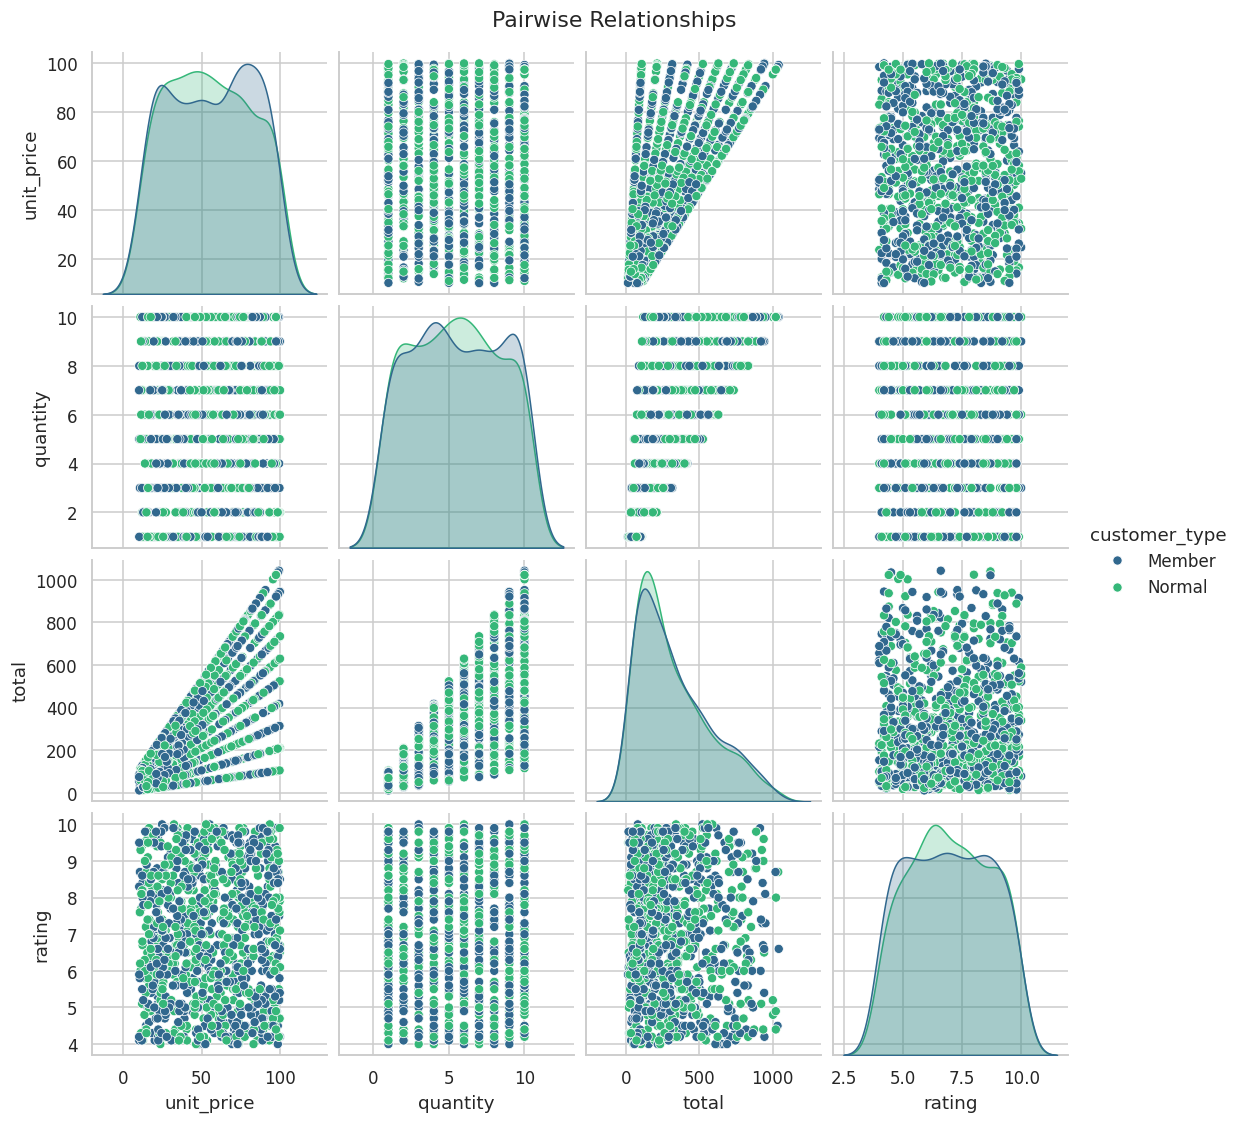

In [38]:
an.plot_pairplot(cleaned_df, ["unit_price", "quantity", "total", "rating"], hue="customer_type")
plt.show()


**Interpretation:** The pairplot confirms visually that Member and Normal customers occupy the same overall value ranges for price, quantity, and total — there's no distinct cluster separating the two segments, reinforcing that customer type has only a modest effect on spending behavior rather than defining fundamentally different shopper profiles.

In [39]:
pivot = cleaned_df.pivot_table(index="city", columns="product_line", values="total", aggfunc="sum")
pivot.style.background_gradient(cmap="viridis", axis=None)


product_line,Electronic accessories,Fashion accessories,Food and beverages,Health and beauty,Home and lifestyle,Sports and travel
city,,,,,,
Mandalay,17051.443500,16413.316500,15214.888500,19980.660000,17549.164500,19988.199000
Naypyitaw,18968.974500,21560.070000,23766.855000,16615.326000,13895.553000,15761.928000
Yangon,18317.113500,16332.508500,17163.100500,12597.753000,22417.195500,19372.699500


**Interpretation:** Revenue by city and product line reveals branch-level specialization — for example, product-line rankings are not identical across all three cities, meaning a one-size-fits-all inventory or promotion strategy would under-serve some branches. This table is used directly in the Recommendations section.

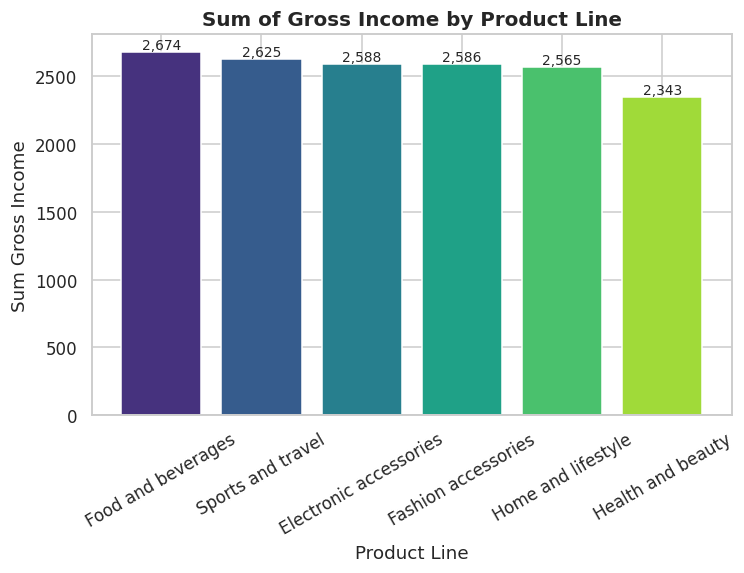

In [40]:
an.plot_grouped_bar(cleaned_df, "product_line", "gross_income")
plt.show()


**Interpretation:** Because `gross_income` is a fixed proportion of `total` for every transaction (constant gross margin), the ranking of product lines by profit is identical to the ranking by revenue — profitability differences across categories in this dataset stem entirely from differences in sales volume/value, not from differing margins.

## 9. Statistical Summary

Consolidated statistics for the core numeric variables, plus grouped statistics that answer
specific business questions directly.


In [41]:
an.summary_statistics(cleaned_df, ["unit_price", "quantity", "total", "gross_income", "rating"])


,count,mean,std,min,25%,50%,75%,max,median,skew
unit_price,1000.0,55.672130,26.494628,10.0800,32.875000,55.230,77.93500,99.96,55.230,0.007077
quantity,1000.0,5.510000,2.923431,1.0000,3.000000,5.000,8.00000,10.00,5.000,0.012941
total,1000.0,322.966749,245.885335,10.6785,124.422375,253.848,471.35025,1042.65,253.848,0.892570
gross_income,1000.0,15.379369,11.708825,0.5085,5.924875,12.088,22.44525,49.65,12.088,0.892570
rating,1000.0,6.972700,1.718580,4.0000,5.500000,7.000,8.50000,10.00,7.000,0.009010


In [42]:
print(f"Total revenue across all transactions: ${cleaned_df['total'].sum():,.2f}")
print(f"Average transaction value (basket size): ${cleaned_df['total'].mean():,.2f}")
print(f"Median transaction value: ${cleaned_df['total'].median():,.2f}")
print(f"Average quantity per transaction: {cleaned_df['quantity'].mean():.2f} items")
print(f"Average customer rating: {cleaned_df['rating'].mean():.2f} / 10")
print(f"Standard deviation of transaction value: ${cleaned_df['total'].std():,.2f}")


Total revenue across all transactions: $322,966.75
Average transaction value (basket size): $322.97
Median transaction value: $253.85
Average quantity per transaction: 5.51 items
Average customer rating: 6.97 / 10
Standard deviation of transaction value: $245.89


In [43]:
cleaned_df.groupby("gender")["total"].agg(["sum", "mean", "count"])


,sum,mean,count
gender,,,
Female,167882.925,335.095659,501
Male,155083.824,310.789226,499


In [44]:
cleaned_df.groupby("payment")["total"].agg(["sum", "mean", "count"]).sort_values("sum", ascending=False)


,sum,mean,count
payment,,,
Cash,112206.570,326.181890,344
Ewallet,109993.107,318.820600,345
Credit card,100767.072,324.009878,311


## 10. Key Questions

### Q1. Which product line generates the highest revenue?
**Food and beverages**, at ≈ \$56,145 total revenue — narrowly ahead of Sports and travel and
Electronic accessories, and ≈ 12% ahead of the lowest-performing line, Health and beauty
(see Section 7 bar chart).

### Q2. Which branch/city performs best, and why?
**Branch C (Naypyitaw)** generates the most total revenue (≈ \$110,569) despite having the
*fewest* transactions of the three branches (328 vs. 340 and 332) — its edge comes from a
higher average basket value, not higher foot traffic (Section 7).

### Q3. Which customer segment contributes the most?
**Member customers** narrowly out-spend Normal customers in total revenue (≈ \$164,223 vs.
≈ \$158,743) with an almost identical transaction count, indicating membership correlates with
modestly larger average baskets rather than significantly more frequent shopping in this window
(Section 7).

### Q4. Are there seasonal / time-based trends?
Yes. Revenue peaks on **Saturdays** (≈ \$56,121, the strongest day) and is weakest on
**Mondays** (≈ \$37,899) — a ≈ 48% swing across the week. At the monthly level, **January**
was the strongest month (≈ \$116,292) and **February** the weakest (≈ \$97,219) within this
3-month window (Section 7, Section 6).

### Q5. Which products/categories perform poorly?
**Health and beauty** is the consistent laggard — lowest total revenue and lowest gross income
of all six product lines, despite a comparable transaction count to the others, meaning its
average basket value is structurally smaller (Section 7, Section 8).

### Q6. Are there strong correlations between numerical variables?
`total`, `tax_5_pct`, `cogs`, and `gross_income` are perfectly correlated by mathematical
construction. Among independent drivers, `quantity` (r = 0.71) correlates more strongly with
`total` than `unit_price` (r = 0.63). Notably, **`rating` is essentially uncorrelated with every
financial variable** (Section 8).

### Q7. What drives higher transaction value — price or quantity?
**Quantity has a slightly stronger relationship with total transaction value than unit price**
(r = 0.71 vs. r = 0.63), suggesting basket-building (buying more items) contributes more to a
larger total than choosing higher-priced items (Section 7, Section 8).

### Q8. Does customer satisfaction relate to how much a customer spends?
**No.** Rating shows negligible correlation with `total`, `unit_price`, or `quantity`
(all |r| < 0.05) — bigger spenders are not systematically happier or unhappier customers, which
means satisfaction should be managed as a separate lever from revenue, not assumed to follow
from it (Section 8).


## 11. Key Insights

1. **Food and beverages is the top revenue category**, generating ≈ \$56,145 (17.4% of total
   revenue) across the 3-month period, narrowly ahead of Sports & travel and Electronic
   accessories.
2. **Health and beauty underperforms every other category**, generating ≈ 12% less revenue
   than the top category despite a similar number of transactions — its average basket value,
   not its popularity, is the gap.
3. **Branch C (Naypyitaw) has the highest revenue per branch (≈ \$110,569) with the fewest
   transactions (328)** of the three branches, meaning it wins on basket size, not footfall.
4. **Saturday is the strongest sales day, generating ≈ 48% more revenue than the weakest day
   (Monday)** — a clear weekly demand cycle.
5. **January was the strongest month (≈ \$116,292) and February the weakest (≈ \$97,219)**
   within the observed window, a ≈ 20% swing.
6. **Member customers contribute ≈ 3.4% more total revenue than Normal customers** on a nearly
   identical number of transactions (501 vs. 499), indicating a modest but real basket-size
   lift from membership.
7. **Cash is the most-used payment method**, followed closely by Ewallet, with Credit card the
   least common — customers lean toward cash/digital-wallet checkout over cards.
8. **Quantity purchased (r = 0.71) is a stronger driver of total transaction value than unit
   price (r = 0.63)**, so basket-building behavior matters more than item price point.
9. **Customer rating is essentially independent of spend** (|r| < 0.05 against total,
   unit price, and quantity) — high spenders are not more satisfied, and low spenders are not
   less satisfied.
10. **9 transactions (0.9% of all sales) are statistical outliers on total value**, all
    representing large, legitimate high-value baskets rather than data-entry errors — no rows
    needed to be removed during cleaning.
11. **The dataset is exceptionally clean**: zero missing values, zero duplicate invoices, zero
    business-rule violations (all totals reconcile exactly to `unit price × quantity × 1.05`),
    which reflects a well-controlled point-of-sale export.
12. **Average customer rating sits at 6.97 / 10 with no ceiling effect**, and varies only
    slightly by product line (6.8–7.1), suggesting satisfaction drivers likely lie outside the
    variables captured in this dataset (e.g. service quality, wait time) rather than in product
    category or price.


## 12. Recommendations

Each recommendation below is explicitly tied to an observed fact and its interpretation, per
the assignment's requirement to keep fact, interpretation, and action distinct.

1. **Invest marketing spend in Food & beverages and Sports & travel.**
   *Fact:* these two lines generate the highest revenue (≈ \$56.1K and ≈ \$55.1K).
   *Interpretation:* they already have proven demand.
   *Action:* prioritize promotional budget and shelf placement here rather than spreading
   spend evenly across all six lines.

2. **Investigate why Health and beauty underperforms despite equal transaction volume.**
   *Fact:* it has a similar transaction count to other lines but ≈ 12% lower total revenue.
   *Interpretation:* average basket value, not customer interest, is the constraint.
   *Action:* test bundling, upselling, or repricing within this category rather than assuming
   it needs more foot traffic.

3. **Study and replicate Branch C's (Naypyitaw) higher-basket-value model.**
   *Fact:* Branch C earns the most total revenue with the fewest transactions.
   *Interpretation:* its customers spend more per visit, possibly due to product mix, staff
   upselling, or local demographics.
   *Action:* audit Branch C's product assortment and staff practices as a template for
   Branches A and B.

4. **Align staffing and promotions with the weekly demand cycle.**
   *Fact:* Saturday revenue is ≈ 48% higher than Monday's.
   *Interpretation:* customer traffic is not evenly distributed across the week.
   *Action:* schedule more staff and run flash promotions on Saturdays; consider
   Monday-specific incentives to smooth demand.

5. **Expand the Membership program.**
   *Fact:* Members generate more total revenue on effectively the same transaction count as
   Normal customers.
   *Interpretation:* membership is associated with (not proven to cause) a modest basket-size
   lift.
   *Action:* run a controlled sign-up campaign for Normal customers and re-measure the revenue
   gap to confirm causality before scaling further investment.

6. **Do not use spend as a proxy for customer satisfaction.**
   *Fact:* rating is uncorrelated with total spend, price, or quantity.
   *Interpretation:* satisfaction is driven by factors outside this dataset (service, wait
   time, store experience).
   *Action:* track satisfaction as its own KPI, and add operational variables (queue time,
   staff-to-customer ratio) to future data collection to find its real drivers.

7. **Continue accepting cash and Ewallet as primary payment rails; don't over-invest in card
   promotions.**
   *Fact:* Cash and Ewallet combined account for the large majority of transactions, with
   Credit card the least-used method.
   *Interpretation:* customers already have a clear preference.
   *Action:* keep card-payment incentives modest and instead ensure cash/Ewallet checkout
   remains fast and frictionless, since that is where the volume already is.

8. **Extend the observation window before making seasonal decisions.**
   *Fact:* the dataset spans only 3 months (Jan–Mar 2019).
   *Interpretation:* the January-high/February-low pattern could reflect a genuine seasonal
   effect or simply short-term noise.
   *Action:* re-run this analysis once a full 12-month dataset is available before committing
   budget to seasonal campaigns.


## 13. Conclusion

This EDA analyzed 1,000 supermarket transactions across three branches over a three-month
period to understand what drives revenue, profitability, and customer satisfaction.

**What was discovered:** The dataset was exceptionally clean (no missing values, duplicates, or
business-rule violations), which allowed the analysis to focus entirely on genuine business
patterns rather than data-quality remediation. Food and beverages emerged as the top revenue
and profit category, while Health and beauty consistently lagged. Branch C (Naypyitaw)
outperformed on revenue per transaction rather than transaction count, and a clear weekly
demand cycle (Saturday peak, Monday trough) was identified.

**Major trends:** A modest membership effect on spend, a stronger relationship between quantity
purchased and total value than between unit price and total value, and a pronounced day-of-week
seasonality.

**Important relationships:** `total`/`tax_5_pct`/`cogs`/`gross_income` are mathematically
identical in relative terms (all derived from the same formula), so they should be treated as
one signal, not four. Most importantly, **customer rating is statistically independent of how
much a customer spends** — a finding with direct implications for how the business should
measure and manage satisfaction separately from revenue.

**Data limitations:** The 3-month window limits confidence in any claimed seasonal pattern;
`gross margin percentage` is constant across all transactions in this export, so no
margin-based (as opposed to volume-based) profitability differences could be analyzed; and the
dataset lacks operational variables (staffing levels, queue time, store size) that could explain
the rating variance left unexplained by financial variables.

**Possible future analysis:** (1) Extend the dataset to a full year to confirm or refute the
seasonal patterns found here; (2) collect operational data (staffing, wait times) to model the
real drivers of customer rating; (3) run a controlled experiment on the Membership program to
establish whether it *causes* higher spend or merely correlates with customers who would have
spent more anyway; (4) analyze margin data if/when it becomes available at the product level
rather than the fixed rate seen in this export.
